## Import thư viện

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [173]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load dữ liệu

In [174]:

train_df = pd.read_csv('/content/drive/MyDrive/Machine_learning/Titanic/train.csv',index_col="PassengerId")
test_df = pd.read_csv('/content/drive/MyDrive/Machine_learning/Titanic/test.csv',index_col="PassengerId")




In [175]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


## Preview Data

In [176]:
print('Loaded:', train_df.shape, test_df.shape)
train_df.head()

Loaded: (891, 11) (418, 10)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [177]:
test_df.tail()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1309,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


## EDA

In [178]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [179]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


### Missing_data


In [180]:
def display_missing_data(df):
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    percent = (missing / len(df)) * 100
    print(pd.DataFrame({'Missing Values': missing, 'Percent (%)': percent.round(2)}))

display_missing_data(train_df)

          Missing Values  Percent (%)
Cabin                687        77.10
Age                  177        19.87
Embarked               2         0.22


In [181]:
display_missing_data(test_df)

       Missing Values  Percent (%)
Cabin             327        78.23
Age                86        20.57
Fare                1         0.24


### Xử lý missing_data

In [182]:

# convert_features=['Pclass','Sex','SibSp','Parch','Embarked']
# train_df['Survived']=train_df['Survived'].astype('category')
# def convert_cat(df, features,type):
#   for feature in features:
#     df[feature]=df[feature].astype(type)
#   return df
# train_pd=convert_cat(train_df,convert_features,'category')
# test_pd=convert_cat(test_df,convert_features,'category')

#### Phân bố của các **Feature**

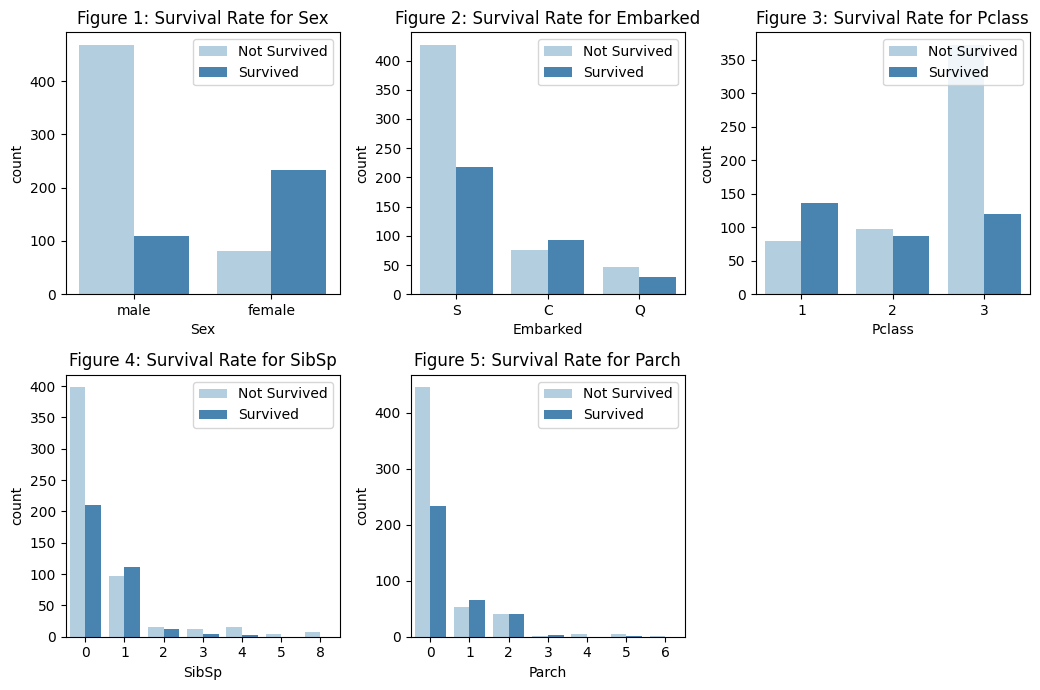

In [183]:
cols = [ 'Sex', 'Embarked', 'Pclass', 'SibSp', 'Parch']

n_rows = 2
n_cols = 3

fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))

for r in range(0, n_rows):
    for c in range(0, n_cols):
        i = r*n_cols + c
        if i < len(cols):
            ax_i = ax[r,c]
            sns.countplot(data=train_df, x=cols[i], hue='Survived', palette='Blues', ax=ax_i)
            ax_i.set_title(f'Figure {i+1}: Survival Rate for {cols[i]}')
            ax_i.legend(title='', loc='upper right', labels=['Not Survived', 'Survived'])
ax.flat[-1].set_visible(False)
plt.tight_layout()

**Tỉ lệ sống sót**:
- Fig 1: Tỉ lệ sống sót của nữ giới cao hơn nam giới.
- Fig 2: Đa phần mọi người đi đến Southampton, và cũng có lượng người không sống sót cao nhất.
- Fig 3: Vé hạng 1 có tỉ lệ sống sót cao hơn.
- Fig 4: Những người với `SibSp` bằng 0 hầu hết sẽ không sống sót, số lượng hành khách đi với 1-2 thành viên gia đình có cơ hội sống sót cao hơn.
- Fig 5: Những người với `Parch` bằng 0 đa phần sẽ không sống sót, số lượng hành khách đi với 1-2 thành viên gia đình có cơ hội sống sót cao hơn.

<Axes: xlabel='Age', ylabel='Count'>

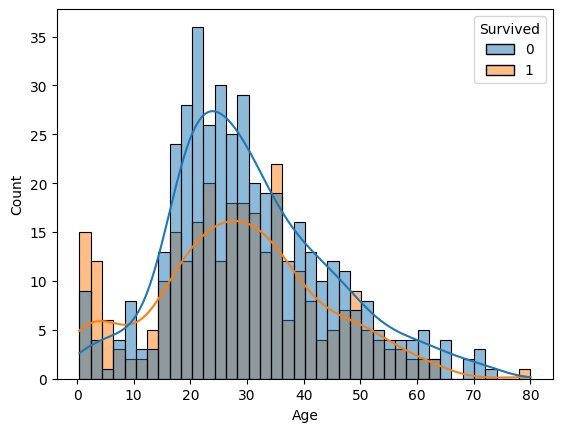

In [184]:
sns.histplot(data=train_df, x='Age', hue='Survived', bins=40, kde=True)

- Đa phần hành khách có độ tuổi từ 18-40 tuổi.
- Trẻ em có nhiều cơ hội sống sót hơn những độ tuổi khác

### FARE

<Axes: xlabel='Fare', ylabel='Count'>

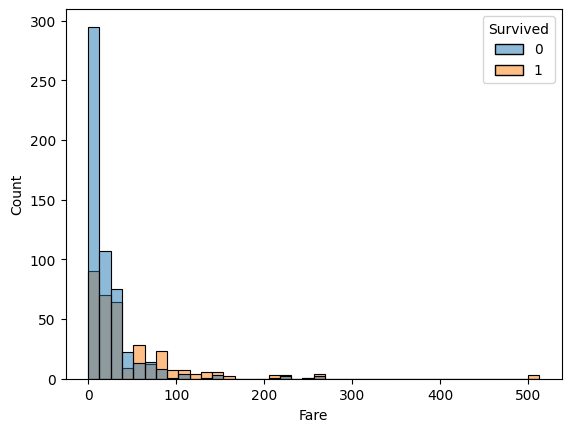

In [185]:
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=40)

<Axes: xlabel='Fare', ylabel='count'>

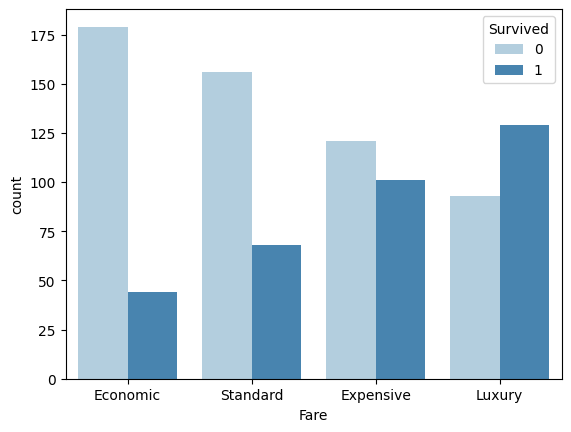

In [186]:
fare_categories=['Economic','Standard','Expensive','Luxury']


quartile_Data=pd.qcut(train_df['Fare'],4,labels=fare_categories)
sns.countplot(x=quartile_Data,hue=train_df['Survived'],palette='Blues')


In [187]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


## Feature Engineering

#### Tạo thêm các biến mới giúp mô hình phân tích chuẩn xác và mạnh hơn

- `Title`: Phản ánh giới tính, địa vị, tầng lớp xã hội.
- `IsFemale`: Giới tính nữ được ưu tiên hơn.
- `FamilySize`: Quy mô gia đình ảnh hưởng tỉ lệ sống, đi cùng thành viên gia đình có tỉ lệ sống sót cao hơn.
- `IsChild`: Đánh dấu trẻ em (dưới 12 tuổi). Trong Titanic, trẻ em thường được cứu trước theo nguyên tắc “women and children first”.
- `IsMother`: Đánh dấu phụ nữ trưởng thành có con đi cùng. Mẹ thường được ưu tiên cứu cùng con.
`Person`: Tuổi + giới tính
`Weath`: Mức giàu

In [188]:
# Feature engineering
def extract_title(name):
    m = re.search(r',\s*([^\.]+)\.', name)
    return m.group(1).strip() if m else ''

title_map = {
    'Capt': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Dr': 'Officer', 'Rev': 'Officer',
    'Don': 'Royalty', 'Sir': 'Royalty', 'Lady': 'Royalty', 'the Countess': 'Royalty', 'Jonkheer': 'Royalty', 'Dona': 'Royalty'
}

for df in [train_df, test_df]:
    # --- Title (Name) ---
    df['Title'] = df['Name'].apply(extract_title)
    df['Title'] = df['Title'].replace(['Mlle','Ms'],'Miss')
    df['Title'] = df['Title'].replace(['Mme'],'Mrs')
    df['Title'] = df['Title'].replace(title_map)
    rare = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
    df['Title'] = df['Title'].replace(list(rare), 'Other')


In [189]:
# Fill missing values
for df in [train_df, test_df]:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    df['Fare'] = df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

    df['Age'] = df.groupby(['Sex','Pclass','Title'])['Age'].transform(lambda x: x.fillna(x.median()))

    # --- Chuẩn hóa log ---
    df['Fare'] = np.log1p(df['Fare'])
    df['Age'] = np.log1p(df['Age'])

display_missing_data(train_df)
display_missing_data(test_df)

       Missing Values  Percent (%)
Cabin             687         77.1
       Missing Values  Percent (%)
Cabin             327        78.23


## Filling Engineering

### FamilySize

In [190]:
train_df['FamilySize'] = train_df['SibSp'].astype(int) + train_df['Parch'].astype(int) + 1
test_df['FamilySize']  = test_df['SibSp'].astype(int)  + test_df['Parch'].astype(int)  + 1


### FamilyCat

In [191]:
train_df['FamilyCat']=pd.cut(train_df['FamilySize'],bins=[0,1,4,6,20], labels=['Solo','Small','Medium','Large'])
test_df['FamilyCat']=pd.cut(test_df['FamilySize'],bins=[0,1,4,6,20], labels=['Solo','Small','Medium','Large'])

### Is_Chill & Is_Mother

In [192]:
# train_df['Age'] = train_df['Age'].astype(float)
# train_df['Parch'] = train_df['Parch'].astype(int)
# train_df['Sex'] = train_df['Sex'].astype(str)
# train_df['Title'] = train_df['Title'].astype(str)

train_df['IsChild'] = (train_df['Age'] < 12).astype(int)
train_df['IsMother'] = ((train_df['Sex'] == 'female') &  (train_df['Parch'] > 0) & (train_df['Age'] > 18) & (train_df['Title'] == 'Mrs')).astype(int)
test_df['IsChild'] = (test_df['Age'] < 12).astype(int)
test_df['IsMother']= ((test_df['Sex'] == 'female') &  (test_df['Parch'] > 0) & (test_df['Age'] > 18) & (test_df['Title'] == 'Mrs')).astype(int)

In [193]:
for df in [train_df, test_df]:
    df['Wealth'] = df['Fare'] / df['Pclass']  # Wealth = Fare / Pclass
    df['IsRichWoman'] = ((df['Sex'] == 'female') &
                          (df['Wealth'] > df['Wealth'].median())).astype(int)


### Cabin & Deck


In [194]:
for df in [train_df, test_df]:
    df['CabinKnown'] = df['Cabin'].notna().astype(int)
    df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')


### Embarked&PClass1


In [195]:
train_df['EmbarkedC_Pclass1'] = ((train_df['Embarked']=='C') & (train_df['Pclass']==1)).astype(int)
test_df['EmbarkedC_Pclass1'] = ((test_df['Embarked']=='C') & (test_df['Pclass']==1)).astype(int)

In [196]:
# train_df['SibSp'] = train_df['SibSp'].astype(int)
# train_df['Parch'] = train_df['Parch'].astype(int)

# # 1️⃣ Nhóm theo vé
# ticket_groups = train_df.groupby('Ticket')

# # 2️⃣ Lọc nhóm có khả năng đi cùng
# suspected_families = []

# for ticket, group in ticket_groups:
#     if len(group) > 1:
#         if group['SibSp'].sum() > 0 or group['Parch'].sum() > 0:
#             suspected_families.append((ticket, group))

# # 3️⃣ In ra ví dụ nhóm đi chung
# for ticket, group in suspected_families[:3]:
#     print(f"🎫 Vé: {ticket}")
#     print(group[['Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']])
#     print("-" * 60)


Ông Emil có SibSp = 1 → có 1 người thân (vợ) đi cùng

Bà Tillie có SibSp = 1 → có chồng đi cùng

Con gái Ruth có SibSp = 0 → không có anh chị em ruột đi cùng |
| Parch | Số cha mẹ / con đi cùng |

Ông Emil có Parch = 1 → có 1 con đi cùng

Bà Tillie có Parch = 1 → cũng có con đi cùng

Con gái Ruth có Parch = 2 → có cả cha và mẹ đi cùng |
| Fare = 79.65 | Tổng tiền vé (cho cả nhóm) |
→ vì họ đi cùng 1 vé nên chia tiền cabin, nên nếu bạn tính FarePerPerson = Fare / PassengerCount = 79.65 / 3 = ~26.55, ta có chi phí bình quân cho mỗi người |

In [197]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,...,Title,FamilySize,FamilyCat,IsChild,IsMother,Wealth,IsRichWoman,CabinKnown,Deck,EmbarkedC_Pclass1
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,3.135494,1,0,A/5 21171,2.110213,NaN,...,Mr,2,Small,1,0,0.703404,0,0,U,0
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,3.663562,1,0,PC 17599,4.280593,C85,...,Mrs,2,Small,1,0,4.280593,1,1,C,1
3,1,3,"Heikkinen, Miss. Laina",female,3.295837,0,0,STON/O2. 3101282,2.188856,NaN,...,Miss,1,Solo,1,0,0.729619,0,0,U,0
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,3.583519,1,0,113803,3.990834,C123,...,Mrs,2,Small,1,0,3.990834,1,1,C,0
5,0,3,"Allen, Mr. William Henry",male,3.583519,0,0,373450,2.202765,NaN,...,Mr,1,Solo,1,0,0.734255,0,0,U,0


In [198]:
test_df.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCat,IsChild,IsMother,Wealth,IsRichWoman,CabinKnown,Deck,EmbarkedC_Pclass1
PassengerId,,,,,,,,,,,,,,,,,,,,
892,3,"Kelly, Mr. James",male,3.569533,0,0,330911,2.178064,NaN,Q,Mr,1,Solo,1,0,0.726021,0,0,U,0
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,3.871201,1,0,363272,2.079442,NaN,S,Mrs,2,Small,1,0,0.693147,0,0,U,0
894,2,"Myles, Mr. Thomas Francis",male,4.143135,0,0,240276,2.369075,NaN,Q,Mr,1,Solo,1,0,1.184537,0,0,U,0
895,3,"Wirz, Mr. Albert",male,3.332205,0,0,315154,2.268252,NaN,S,Mr,1,Solo,1,0,0.756084,0,0,U,0
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,3.135494,1,1,3101298,2.586824,NaN,S,Mrs,3,Small,1,0,0.862275,0,0,U,0


### Tuổi và PClass

In [199]:
for df in [train_df, test_df]:
    df['Age*Pclass'] = df['Age'] * df['Pclass']


In [200]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Survived           891 non-null    int64   
 1   Pclass             891 non-null    int64   
 2   Name               891 non-null    object  
 3   Sex                891 non-null    object  
 4   Age                891 non-null    float64 
 5   SibSp              891 non-null    int64   
 6   Parch              891 non-null    int64   
 7   Ticket             891 non-null    object  
 8   Fare               891 non-null    float64 
 9   Cabin              204 non-null    object  
 10  Embarked           891 non-null    object  
 11  Title              891 non-null    object  
 12  FamilySize         891 non-null    int64   
 13  FamilyCat          891 non-null    category
 14  IsChild            891 non-null    int64   
 15  IsMother           891 non-null    int64   
 16  Wealth       

In [201]:

cat_cols = ['Embarked', 'Title', 'Deck', 'FamilyCat']
bin_cols = ['Sex', 'IsChild', 'IsMother', 'IsRichWoman']
num_cols = ['Age', 'Fare', 'FamilySize', 'Wealth', 'Age*Pclass']
for df in [train_df, test_df]:
    df['Sex'] = (
        df['Sex'].astype(str)  # đảm bảo là chuỗi
        .str.strip()            # loại bỏ khoảng trắng thừa
        .str.lower()            # viết thường toàn bộ
        .map({'male': 0, 'female': 1})  # ánh xạ
        .fillna(0)              # nếu có lỗi map thì gán 0
        .astype(int)
    )

feature_cols = num_cols + bin_cols + \
 [col for col in train_df.columns if any(x in col for x in cat_cols)]
feature_cols = num_cols + bin_cols + \
 [col for col in train_df.columns if any(x in col for x in cat_cols)]




In [202]:
# 1️⃣ Encode categorical variables
train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

# 2️⃣ Tách nhãn trước khi align
y = train_df['Survived']
train_features = train_df.drop('Survived', axis=1)

# 3️⃣ Align (đồng bộ cột giữa train/test)
train_features, test_df = train_features.align(test_df, join='outer', axis=1, fill_value=0)

# 4️⃣ Dùng lại biến train/test
X_train_full = train_features
X_test_final = test_df


In [203]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Survived           891 non-null    int64  
 1   Pclass             891 non-null    int64  
 2   Name               891 non-null    object 
 3   Sex                891 non-null    int64  
 4   Age                891 non-null    float64
 5   SibSp              891 non-null    int64  
 6   Parch              891 non-null    int64  
 7   Ticket             891 non-null    object 
 8   Fare               891 non-null    float64
 9   Cabin              204 non-null    object 
 10  FamilySize         891 non-null    int64  
 11  IsChild            891 non-null    int64  
 12  IsMother           891 non-null    int64  
 13  Wealth             891 non-null    float64
 14  IsRichWoman        891 non-null    int64  
 15  CabinKnown         891 non-null    int64  
 16  EmbarkedC_Pclass1  891 non-null

## Model training


### Logistic

In [204]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# ==== 1. Feature selection ====
feature_cols = num_cols + bin_cols + [
    col for col in train_df.columns if any(cat in col for cat in cat_cols)
]

X = train_df[feature_cols]
y = train_df['Survived']
X_test_final = test_df[feature_cols]

# ==== 2. Split train/validation ====
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# ==== 3. Scale numeric features ====
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])

# ==== 4. Define models ====
models = {
    "Logistic Regression": LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="logloss", random_state=42)
}

results = []

# ==== 5. Train & Evaluate ====
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_val_pred)
    roc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    print(f"Validation Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_val, y_val_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_val_pred))
    print(f"ROC AUC: {roc:.4f}")

    results.append({"Model": name, "Accuracy": acc, "ROC AUC": roc})

    # ==== Save submission for each model ====
    y_test_pred = model.predict(X_test_final)
    submission = pd.DataFrame({
        "PassengerId": test_df.index,
        "Survived": y_test_pred
    })
    submission.to_csv(f"/content/drive/MyDrive/Machine_learning/Titanic/submission_{name.replace(' ', '_')}.csv", index=False)

# ==== 6. Show summary table ====
results_df = pd.DataFrame(results).sort_values(by="ROC AUC", ascending=False)
print("\n📊 Model comparison:\n", results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best model: {best_model_name}")



🔹 Training Logistic Regression...
Validation Accuracy: 0.8324

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85       105
           1       0.78      0.84      0.81        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.83      0.83       179


Confusion Matrix:
 [[87 18]
 [12 62]]
ROC AUC: 0.8943

🔹 Training Random Forest...


/tmp/ipython-input-275240450.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test_final[num_cols] = scaler.transform(X_test_final[num_cols])


Validation Accuracy: 0.8547

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88       105
           1       0.82      0.82      0.82        74

    accuracy                           0.85       179
   macro avg       0.85      0.85      0.85       179
weighted avg       0.85      0.85      0.85       179


Confusion Matrix:
 [[92 13]
 [13 61]]
ROC AUC: 0.9183

🔹 Training Gradient Boosting...
Validation Accuracy: 0.8380

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.86       105
           1       0.81      0.80      0.80        74

    accuracy                           0.84       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179


Confusion Matrix:
 [[91 14]
 [15 59]]
ROC AUC: 0.9069

🔹 Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [03:18:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Validation Accuracy: 0.8212

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84       105
           1       0.76      0.82      0.79        74

    accuracy                           0.82       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.82      0.82      0.82       179


Confusion Matrix:
 [[86 19]
 [13 61]]
ROC AUC: 0.9021

📊 Model comparison:
                  Model  Accuracy   ROC AUC
1        Random Forest  0.854749  0.918340
2    Gradient Boosting  0.837989  0.906885
3              XGBoost  0.821229  0.902059
0  Logistic Regression  0.832402  0.894337

🏆 Best model: Random Forest


In [205]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                418 non-null    float64
 1   Age*Pclass         418 non-null    float64
 2   Cabin              91 non-null     object 
 3   CabinKnown         418 non-null    int64  
 4   Deck_B             418 non-null    bool   
 5   Deck_C             418 non-null    bool   
 6   Deck_D             418 non-null    bool   
 7   Deck_E             418 non-null    bool   
 8   Deck_F             418 non-null    bool   
 9   Deck_G             418 non-null    bool   
 10  Deck_T             418 non-null    int64  
 11  Deck_U             418 non-null    bool   
 12  EmbarkedC_Pclass1  418 non-null    int64  
 13  Embarked_Q         418 non-null    bool   
 14  Embarked_S         418 non-null    bool   
 15  FamilyCat_Large    418 non-null    bool   
 16  FamilyCat_Medium   418 non-n